# Overview

- heart disease prediction with [Extra Trees Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html)
- hyper parameter tuning using [optuna](https://optuna.org/)

# Installs/Imports

In [1]:
! pip install -U optuna -qq

In [2]:
### basics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("bmh")

### model
from sklearn.ensemble import ExtraTreesClassifier

### optimization
import optuna

### misc
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [3]:
print(f'optuna version: {optuna.__version__}')

optuna version: 3.5.0


# Load data

- [Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)


In [4]:
df = pd.read_csv('/kaggle/input/heart-disease-dataset/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
df.isnull().values.any()

False

In [6]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


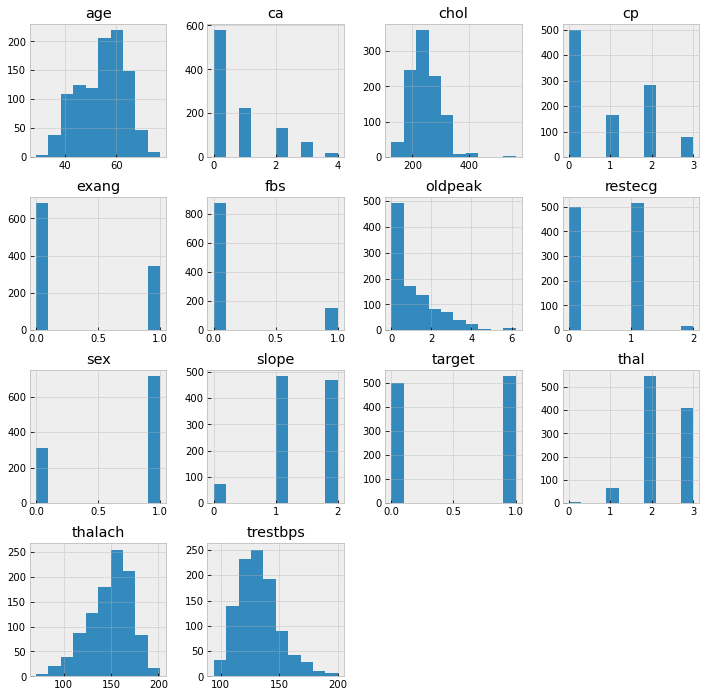

In [8]:
df.hist(figsize = (12, 12));

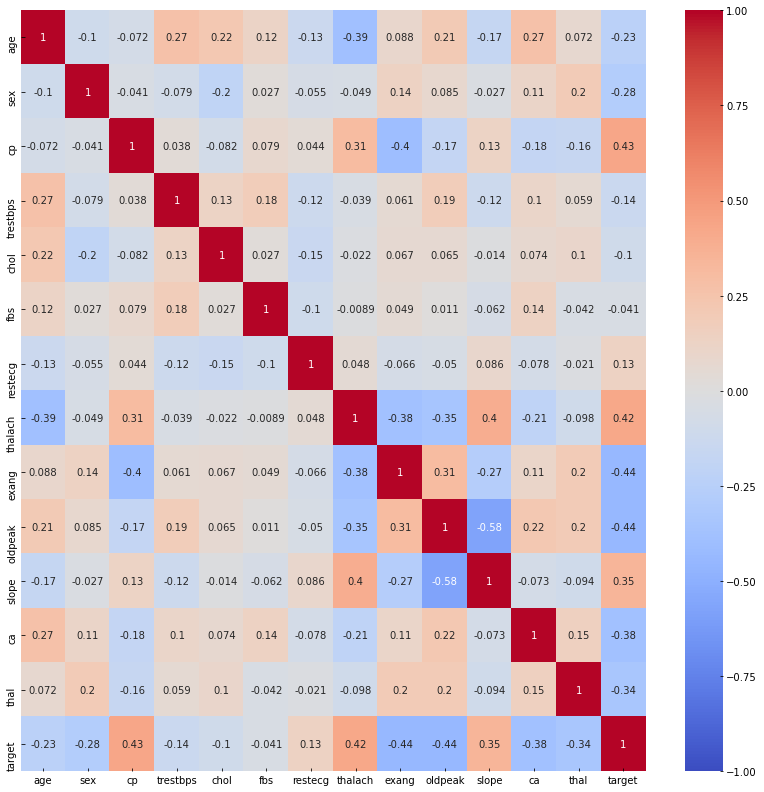

In [9]:
corr = df.corr()
plt.figure(figsize=(14,14))
sns.heatmap(corr, annot = True, vmin=-1, vmax=1, center= 0, cmap= 'coolwarm'); # greens

# Features and target

In [10]:
features_names = [c for c in df.columns if c != 'target']
target_name = 'target'

features = df.loc[:, features_names]
target = df.loc[:, target_name]

# Split

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    features, 
    target,
    test_size = 0.15,
    stratify = target,
    random_state = 0
)

print(f'X_train: {X_train.shape}')
print(f'X_valid: {X_valid.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_valid: {y_valid.shape}')

X_train: (871, 13)
X_valid: (154, 13)
y_train: (871,)
y_valid: (154,)


# Model

- Extra Trees Classifier

In [12]:
def etr(X_train, y_train, X_valid, y_valid):
  
  ### instantiate model
  etr = ExtraTreesClassifier(
      n_estimators = 100,
      max_depth = 12,
      criterion = 'gini',
      bootstrap = False,
      class_weight = None,
      warm_start = True,
      max_leaf_nodes = 20,
      random_state = 0
  )

  etr.fit(X_train, y_train) # train on train data
  etr_score = round(etr.score(X_valid, y_valid), 5) # validate on validation data

  print('ExtraTreesClassifier score: ', etr_score)

  return etr_score

In [13]:
etr_score = etr(X_train, y_train, X_valid, y_valid)

ExtraTreesClassifier score:  0.88312


# Tuning with Optuna

- Hyper Parameter Optimization
- [Optuna docs](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html)

In [14]:
def objective(trial):

    ### define params grid to search maximum accuracy
    n_estimators = trial.suggest_int('n_estimators', 50, 120)
    max_depth = trial.suggest_int('max_depth', 10, 16)
    max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 15, 25)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    ### modeling with suggested params
    model = ExtraTreesClassifier(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_leaf_nodes = max_leaf_nodes,
        criterion = criterion,
        random_state = 0
    ) # do not tune the seed

    ### cross validation score
    # score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=3)
    # etr_score = score.mean()

    ### fit
    model.fit(X_train, y_train) # train on train data
    accuracy = round(model.score(X_valid, y_valid), 5) # validate on validation data

    return accuracy

In [15]:
study = optuna.create_study(direction='maximize') # maximize accuracy
study.optimize(objective, n_trials=30)

[I 2024-03-08 13:58:59,411] A new study created in memory with name: no-name-76c40b67-9b0c-434c-9fd8-c5194b05bbf6
[I 2024-03-08 13:58:59,572] Trial 0 finished with value: 0.8961 and parameters: {'n_estimators': 98, 'max_depth': 15, 'max_leaf_nodes': 25, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8961.
[I 2024-03-08 13:58:59,758] Trial 1 finished with value: 0.88961 and parameters: {'n_estimators': 116, 'max_depth': 11, 'max_leaf_nodes': 23, 'criterion': 'gini'}. Best is trial 0 with value: 0.8961.
[I 2024-03-08 13:58:59,859] Trial 2 finished with value: 0.88312 and parameters: {'n_estimators': 58, 'max_depth': 10, 'max_leaf_nodes': 20, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8961.
[I 2024-03-08 13:59:00,007] Trial 3 finished with value: 0.88961 and parameters: {'n_estimators': 88, 'max_depth': 11, 'max_leaf_nodes': 22, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8961.
[I 2024-03-08 13:59:00,188] Trial 4 finished with value: 0.8961 and parameters: {

In [16]:
### best params
study.best_trial.params

{'n_estimators': 98,
 'max_depth': 15,
 'max_leaf_nodes': 25,
 'criterion': 'entropy'}

In [17]:
### best score (accuracy)
study.best_value

0.8961

In [18]:
### param importances dictionary
optuna.importance.get_param_importances(study)

{'max_leaf_nodes': 0.8849949268027925,
 'n_estimators': 0.07455944058443287,
 'max_depth': 0.030019763478132122,
 'criterion': 0.010425869134642642}

# Optuna visualization

In [19]:
### plot param importances
optuna.visualization.plot_param_importances(study)

In [20]:
### plot optimization history
optuna.visualization.plot_optimization_history(study)

In [21]:
### plot parallel coordinate
optuna.visualization.plot_parallel_coordinate(study)

In [22]:
### slice plot
optuna.visualization.plot_slice(study)

# Results

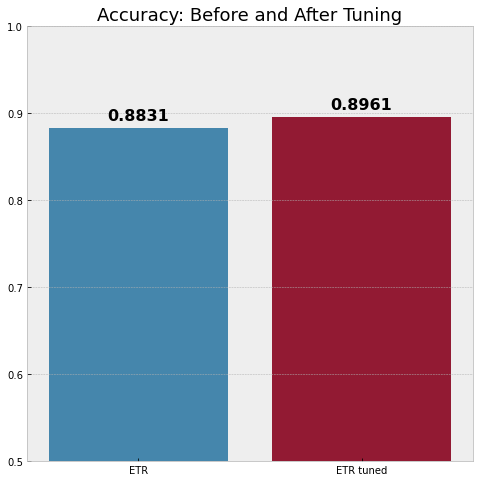

In [23]:
names = np.array(['ETR', 'ETR tuned'])
values = np.array([etr_score, study.best_value])

plt.figure(figsize=(8,8))
plt.title("Accuracy: Before and After Tuning", fontsize=18)
plt.ylim(0.5, 1)
bar1 = sns.barplot(x = names, y = values);

for p in bar1.patches:
  _x = p.get_x() + p.get_width() / 2
  _y = p.get_y() + p.get_height() + (p.get_height()*0.01)
  value = '{:.4f}'.format(p.get_height())
  plt.text(_x, _y, value, ha="center", fontsize=16, fontweight = 'bold') 

# Conclusions

**<font color='orange'>Upvote if you found value in this notebook!</font>** 😀